In [1]:
import os
import sys
import time
import numpy
import pygicp
from matplotlib import pyplot

In [3]:
def pose_distance(p1, p2):
    """Euclidean distance between translations of two 4x4 poses."""
    return numpy.linalg.norm(p1[:3, 3] - p2[:3, 3])

def trajectory_distances(poses):
    """Cumulative distances along trajectory."""
    dists = [0.0]
    for i in range(1, len(poses)):
        dists.append(dists[-1] + pose_distance(poses[i - 1], poses[i]))
    return numpy.array(dists, dtype=numpy.float64)

def rotation_error_rad(T_err):
    """Angle of rotation (rad) from a 4x4 error transform."""
    R = T_err[:3, :3]
    tr = numpy.trace(R)
    c = (tr - 1.0) * 0.5
    c = numpy.clip(c, -1.0, 1.0)
    return float(numpy.arccos(c))

def compute_kitti_segment_errors(est_poses, gt_poses, segment_lengths=(100, 200, 300, 400, 500, 600, 700, 800)):
    """
    KITTI odometry-style errors:
      - translational drift: % of segment length
      - rotational drift: degrees per meter
    """
    assert len(est_poses) == len(gt_poses), "est and gt must have same length"
    n = len(gt_poses)
    gt_dists = trajectory_distances(gt_poses)

    results = {L: {"t_perc": [], "r_deg_per_m": []} for L in segment_lengths}

    for i in range(n):
        for L in segment_lengths:
            target_dist = gt_dists[i] + L
            j = numpy.searchsorted(gt_dists, target_dist, side="left")
            if j >= n:
                continue

            T_gt_rel  = numpy.linalg.inv(gt_poses[i]) @ gt_poses[j]
            T_est_rel = numpy.linalg.inv(est_poses[i]) @ est_poses[j]

            T_err = numpy.linalg.inv(T_gt_rel) @ T_est_rel

            t_err = numpy.linalg.norm(T_err[:3, 3])
            r_err = rotation_error_rad(T_err)

            results[L]["t_perc"].append((t_err / L) * 100.0)
            results[L]["r_deg_per_m"].append((r_err / L) * (180.0 / numpy.pi))

    summary = {}
    for L in segment_lengths:
        t_list = numpy.array(results[L]["t_perc"], dtype=numpy.float64)
        r_list = numpy.array(results[L]["r_deg_per_m"], dtype=numpy.float64)
        summary[L] = {
            "count": int(len(t_list)),
            "t_perc_mean": float(t_list.mean()) if len(t_list) else float("nan"),
            "r_deg_per_m_mean": float(r_list.mean()) if len(r_list) else float("nan"),
        }

    all_t = numpy.concatenate([numpy.array(results[L]["t_perc"], dtype=numpy.float64) for L in segment_lengths if len(results[L]["t_perc"])])
    all_r = numpy.concatenate([numpy.array(results[L]["r_deg_per_m"], dtype=numpy.float64) for L in segment_lengths if len(results[L]["r_deg_per_m"])])
    overall = {
        "t_perc_mean": float(all_t.mean()) if all_t.size else float("nan"),
        "r_deg_per_m_mean": float(all_r.mean()) if all_r.size else float("nan"),
        "num_samples": int(all_t.size),
    }

    return summary, overall

def read_calib_file(filepath):
    """Read in a calibration file and parse into a dictionary."""
    data = {}

    with open(filepath, 'r') as f:
        for line in f.readlines():
            try:
                key, value = line.split(':', 1)
            except ValueError:
                key, value = line.split(' ', 1)
            try:
                data[key] = numpy.array([float(x) for x in value.split()])
            except ValueError:
                pass

    return data

In [4]:
def load_sequence(kitti_path, sequence):
    seq_path = os.path.join(kitti_path, 'sequences', sequence, 'velodyne')
    filenames = sorted([seq_path + '/' + x for x in os.listdir(seq_path) if x.endswith('.bin')])

    calib_data = {}
    calib_filepath = os.path.join(kitti_path, 'calibration', 'sequences', sequence, 'calib.txt')
    filedata = read_calib_file(calib_filepath)

    P_rect_00 = numpy.reshape(filedata['P0'], (3, 4))
    P_rect_10 = numpy.reshape(filedata['P1'], (3, 4))
    P_rect_20 = numpy.reshape(filedata['P2'], (3, 4))
    P_rect_30 = numpy.reshape(filedata['P3'], (3, 4))

    calib_data['P_rect_00'] = P_rect_00
    calib_data['P_rect_10'] = P_rect_10
    calib_data['P_rect_20'] = P_rect_20
    calib_data['P_rect_30'] = P_rect_30

    T1 = numpy.eye(4)
    T1[0, 3] = P_rect_10[0, 3] / P_rect_10[0, 0]
    T2 = numpy.eye(4)
    T2[0, 3] = P_rect_20[0, 3] / P_rect_20[0, 0]
    T3 = numpy.eye(4)
    T3[0, 3] = P_rect_30[0, 3] / P_rect_30[0, 0]

    calib_data['T_cam0_velo'] = numpy.reshape(filedata['Tr'], (3, 4))
    calib_data['T_cam0_velo'] = numpy.vstack([calib_data['T_cam0_velo'], [0, 0, 0, 1]])

    pose_file = os.path.join(kitti_path, 'poses', sequence + '.txt')
    gt_poses = []
    with open(pose_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            T_w_cam0 = numpy.fromstring(line, dtype=float, sep=' ')
            T_w_cam0 = T_w_cam0.reshape(3, 4)
            T_w_cam0 = numpy.vstack((T_w_cam0, [0, 0, 0, 1]))
            gt_poses.append(T_w_cam0 @ calib_data['T_cam0_velo'])
    
    return gt_poses, filenames

In [5]:
kitti_path = '/home/igo320341/Desktop/Research/datasets/kitti_odometry'

# Sequence 00

## GICP

Avg fps: 16.453601129123758

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    4441 |   1.701 |   0.015779
     200 |    4309 |   2.034 |   0.012835
     300 |    4233 |   2.390 |   0.011466
     400 |    4154 |   2.649 |   0.010229
     500 |    4073 |   2.723 |   0.009277
     600 |    3987 |   2.553 |   0.008269
     700 |    3843 |   2.282 |   0.007266
     800 |    3749 |   2.134 |   0.006445

Overall: t_err[%]=2.302, r_err[deg/m]=0.010346, samples=32789


(-299.4501858000995, 320.3950483791649, -74.66082195073527, 504.915339201079)

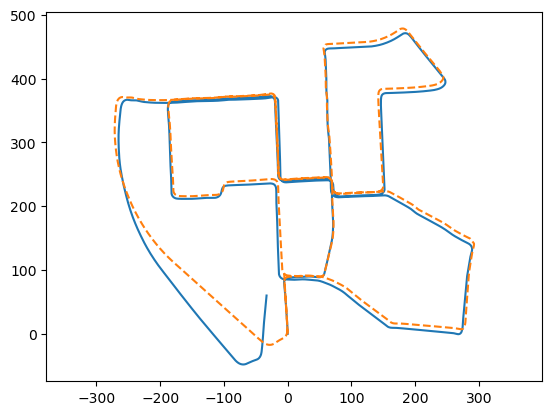

In [ ]:
gt_poses, filenames = load_sequence(kitti_path, '00')

reg = pygicp.FastGICP()
reg.set_num_threads(0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 22.532984962007312

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    4441 |   0.940 |   0.007089
     200 |    4309 |   0.980 |   0.005476
     300 |    4233 |   1.006 |   0.004795
     400 |    4154 |   1.042 |   0.004395
     500 |    4073 |   1.052 |   0.004079
     600 |    3987 |   1.008 |   0.003646
     700 |    3843 |   1.006 |   0.003151
     800 |    3749 |   1.004 |   0.002903

Overall: t_err[%]=1.004, r_err[deg/m]=0.004507, samples=32789


(-299.4501858000995, 320.3950483791649, -42.79247056447525, 503.3977986588762)

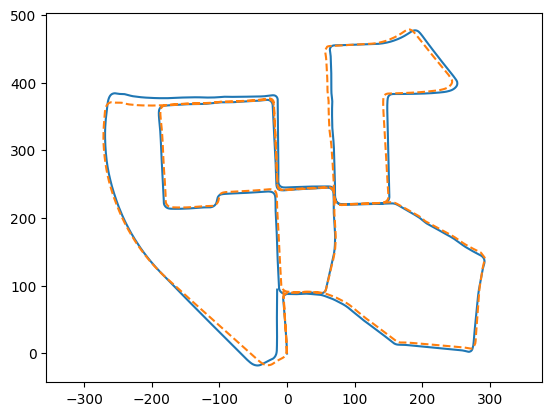

In [86]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 71.69580907510537

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    4441 |   1.250 |   0.012644
     200 |    4309 |   1.262 |   0.009187
     300 |    4233 |   1.275 |   0.007762
     400 |    4154 |   1.315 |   0.007016
     500 |    4073 |   1.340 |   0.006330
     600 |    3987 |   1.254 |   0.005627
     700 |    3843 |   1.185 |   0.005042
     800 |    3749 |   1.169 |   0.004666

Overall: t_err[%]=1.258, r_err[deg/m]=0.007406, samples=32789


(-299.5409019115538,
 322.30008671970603,
 -45.991848686235834,
 507.8453977324097)

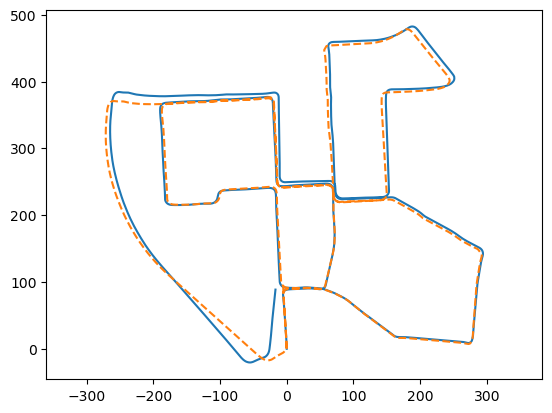

In [8]:
gt_poses, filenames = load_sequence(kitti_path, '00')

reg = pygicp.FastSVGICP()
reg.set_num_threads(0)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 01

## GICP

Avg fps: 6.153109360708565

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    1034 |   1.942 |   0.010690
     200 |     972 |   2.526 |   0.010158
     300 |     907 |   3.292 |   0.009861
     400 |     848 |   4.143 |   0.009770
     500 |     802 |   5.019 |   0.009803
     600 |     759 |   5.939 |   0.009885
     700 |     720 |   6.893 |   0.009929
     800 |     682 |   7.801 |   0.010040

Overall: t_err[%]=4.429, r_err[deg/m]=0.010041, samples=6724


(-93.4204307937796, 1961.5653854851141, -1194.2013877626262, 79.13704869900639)

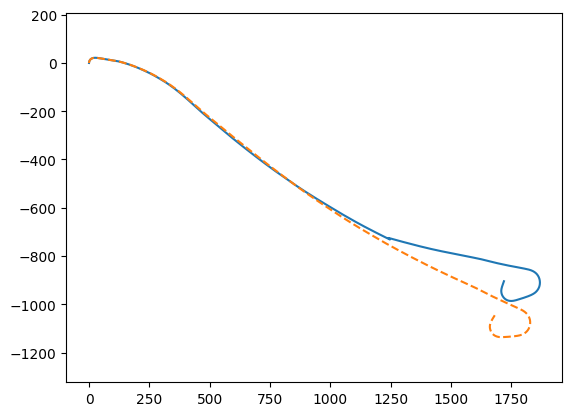

In [88]:
gt_poses, filenames = load_sequence(kitti_path, '01')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 15.668995375419941

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    1034 |   1.251 |   0.008359
     200 |     972 |   1.677 |   0.007840
     300 |     907 |   2.209 |   0.007667
     400 |     848 |   2.811 |   0.007720
     500 |     802 |   3.449 |   0.007806
     600 |     759 |   4.117 |   0.007882
     700 |     720 |   4.795 |   0.007927
     800 |     682 |   5.482 |   0.007963

Overall: t_err[%]=3.033, r_err[deg/m]=0.007904, samples=6724


(-91.40469092954451,
 1919.2348483361775,
 -1194.2007608587423,
 79.12388371744484)

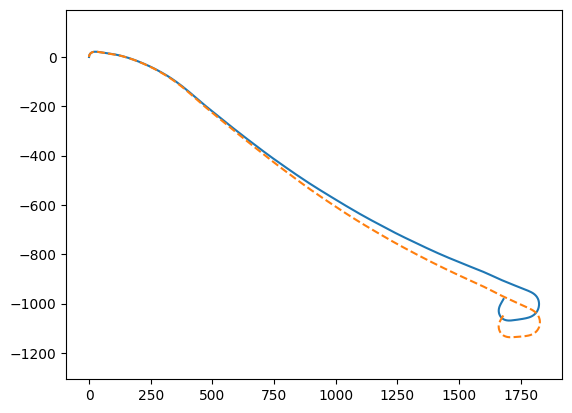

In [89]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 17.954871114845098

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    1034 |   2.791 |   0.010067
     200 |     972 |   2.871 |   0.009103
     300 |     907 |   3.124 |   0.008824
     400 |     848 |   3.614 |   0.008796
     500 |     802 |   4.187 |   0.008773
     600 |     759 |   4.817 |   0.008805
     700 |     720 |   5.455 |   0.008834
     800 |     682 |   6.140 |   0.008867

Overall: t_err[%]=3.971, r_err[deg/m]=0.009049, samples=6724


(-91.40469092954451,
 1919.2348483361775,
 -1244.1827777375072,
 81.50397975929079)

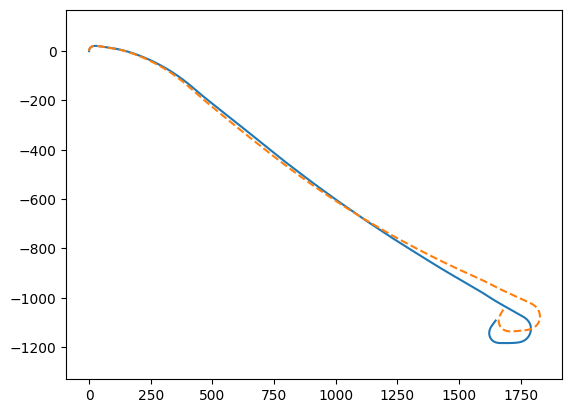

In [90]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 02

## GICP

Avg fps: 9.89331152005856

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    4585 |   1.278 |   0.008298
     200 |    4509 |   1.419 |   0.006961
     300 |    4436 |   1.614 |   0.006282
     400 |    4362 |   1.832 |   0.005906
     500 |    4290 |   2.055 |   0.005502
     600 |    4211 |   2.251 |   0.005168
     700 |    4103 |   2.353 |   0.004838
     800 |    3999 |   2.373 |   0.004459

Overall: t_err[%]=1.880, r_err[deg/m]=0.005975, samples=34495


(-30.64026714119691, 627.7278418807263, -75.16895987190036, 970.834760232222)

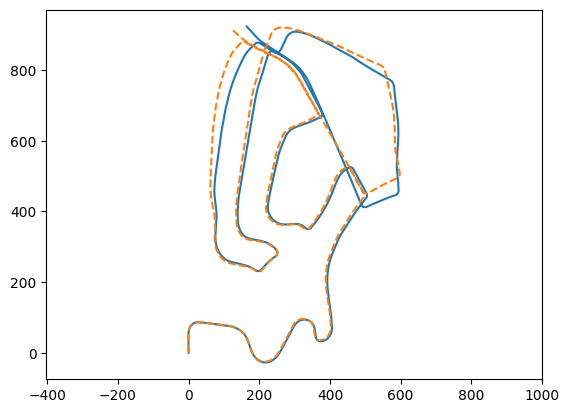

In [91]:
gt_poses, filenames = load_sequence(kitti_path, '02')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 21.704600884189883

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    4585 |   1.466 |   0.007087
     200 |    4509 |   1.467 |   0.006408
     300 |    4436 |   1.599 |   0.005657
     400 |    4362 |   1.751 |   0.005039
     500 |    4290 |   1.884 |   0.004598
     600 |    4211 |   1.971 |   0.004198
     700 |    4103 |   1.973 |   0.003785
     800 |    3999 |   1.935 |   0.003445

Overall: t_err[%]=1.748, r_err[deg/m]=0.005078, samples=34495


(-30.64026714119691, 627.7278418807263, -74.20066624403883, 967.474821161468)

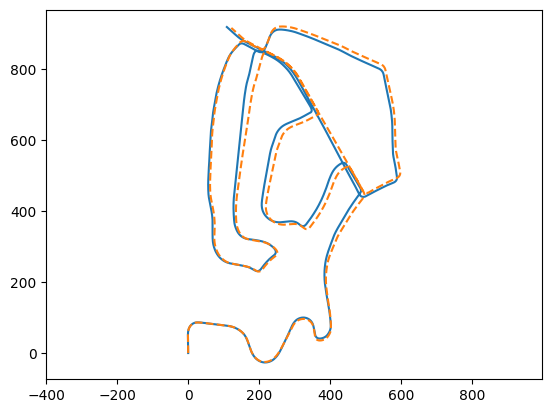

In [92]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 24.354358424419196

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    4585 |   3.201 |   0.012627
     200 |    4509 |   3.249 |   0.010604
     300 |    4436 |   3.154 |   0.009236
     400 |    4362 |   3.129 |   0.008296
     500 |    4290 |   3.156 |   0.007586
     600 |    4211 |   3.224 |   0.007017
     700 |    4103 |   3.242 |   0.006442
     800 |    3999 |   3.245 |   0.005861

Overall: t_err[%]=3.199, r_err[deg/m]=0.008547, samples=34495


(-32.660580823962974, 670.1544292188136, -72.72545770639633, 967.4045731358659)

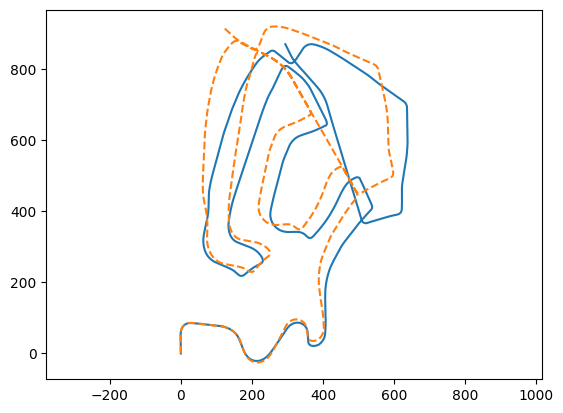

In [93]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 03

## GICP

Avg fps: 6.741546734626824

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     613 |   1.291 |   0.009293
     200 |     484 |   1.519 |   0.008548
     300 |     368 |   1.762 |   0.007708
     400 |     247 |   1.825 |   0.006804
     500 |     104 |   2.264 |   0.006315
     600 |       0 |     nan |        nan
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=1.576, r_err[deg/m]=0.008264, samples=1816


(-25.117272628580597,
 501.626083904484,
 -10.210922699717596,
 208.44245577263786)

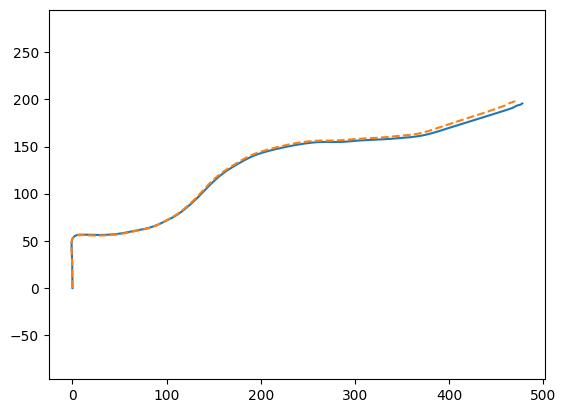

In [94]:
gt_poses, filenames = load_sequence(kitti_path, '03')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 17.215991762222785

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     613 |   1.290 |   0.007937
     200 |     484 |   1.552 |   0.007227
     300 |     368 |   1.970 |   0.006487
     400 |     247 |   2.108 |   0.006133
     500 |     104 |   2.455 |   0.005919
     600 |       0 |     nan |        nan
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=1.676, r_err[deg/m]=0.007093, samples=1816


(-25.023195963509885,
 499.5521220231035,
 -10.388342989339169,
 212.1682818546909)

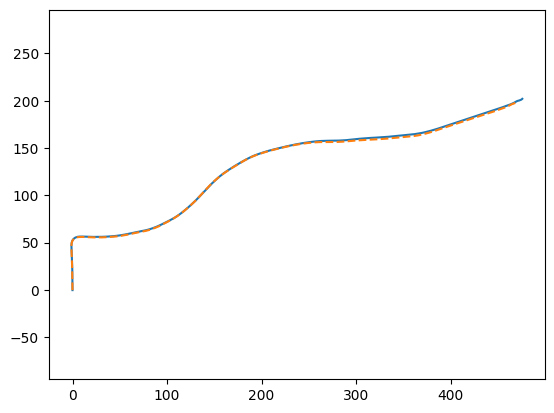

In [95]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 18.746378767529915

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     613 |   3.583 |   0.010428
     200 |     484 |   3.919 |   0.007163
     300 |     368 |   4.098 |   0.005116
     400 |     247 |   4.062 |   0.004607
     500 |     104 |   3.883 |   0.005741
     600 |       0 |     nan |        nan
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=3.859, r_err[deg/m]=0.007421, samples=1816


(-25.4691958617607, 509.01647180126616, -10.507263557922522, 214.6656137949413)

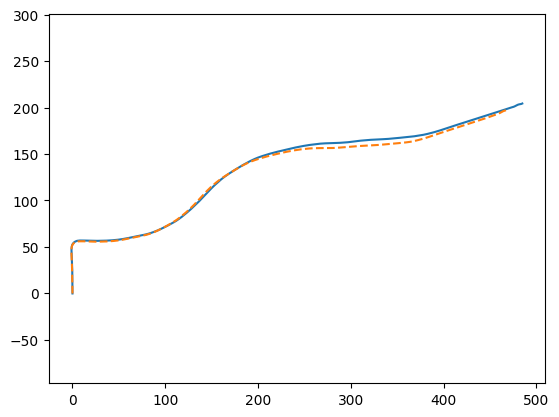

In [96]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 04

## GICP

Avg fps: 5.489781325721509

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     208 |   1.263 |   0.008750
     200 |     142 |   1.615 |   0.008281
     300 |      68 |   2.212 |   0.008053
     400 |       0 |     nan |        nan
     500 |       0 |     nan |        nan
     600 |       0 |     nan |        nan
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=1.537, r_err[deg/m]=0.008477, samples=418


(-2.057769116587006,
 0.12796809167474346,
 -20.069078094020156,
 414.10271023207764)

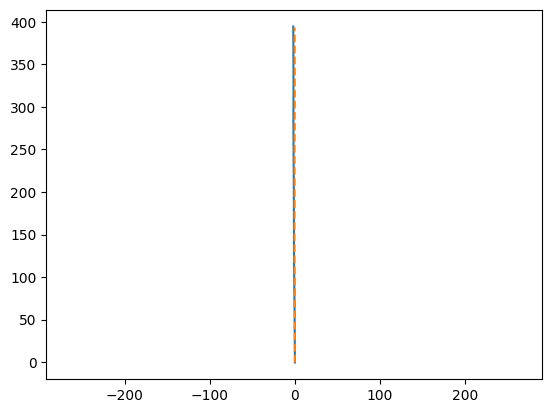

In [97]:
gt_poses, filenames = load_sequence(kitti_path, '04')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 15.23093373418196

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     208 |   1.240 |   0.008764
     200 |     142 |   1.345 |   0.008168
     300 |      68 |   1.685 |   0.007776
     400 |       0 |     nan |        nan
     500 |       0 |     nan |        nan
     600 |       0 |     nan |        nan
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=1.348, r_err[deg/m]=0.008401, samples=418


(-1.2257259201471025,
 0.08834698708236711,
 -20.098249996962608,
 414.7153201938691)

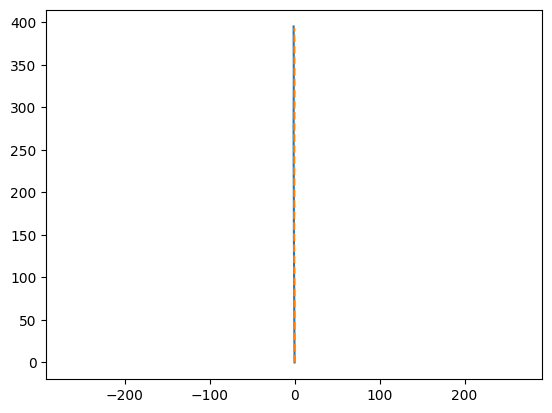

In [98]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 16.770477883184252

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     208 |   6.726 |   0.008611
     200 |     142 |   4.733 |   0.007859
     300 |      68 |   3.660 |   0.007510
     400 |       0 |     nan |        nan
     500 |       0 |     nan |        nan
     600 |       0 |     nan |        nan
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=5.550, r_err[deg/m]=0.008177, samples=418


(-0.6311503721828094, 1.721166848677692, -20.011894049307458, 412.901845293111)

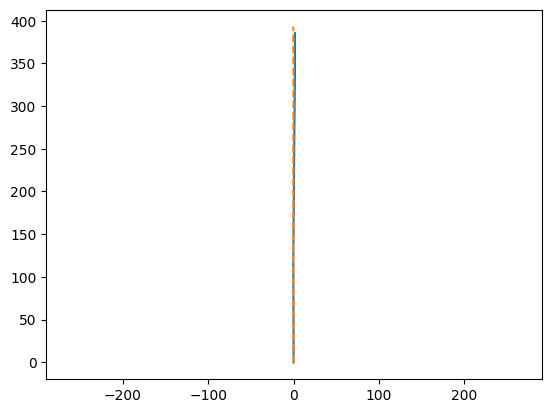

In [99]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 05

## GICP

Avg fps: 10.535772817240359

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    2668 |   0.788 |   0.010301
     200 |    2573 |   0.869 |   0.008021
     300 |    2479 |   0.877 |   0.006816
     400 |    2267 |   0.812 |   0.005887
     500 |    2177 |   0.881 |   0.005206
     600 |    2049 |   0.867 |   0.004674
     700 |    1952 |   0.846 |   0.004392
     800 |    1861 |   0.844 |   0.004238

Overall: t_err[%]=0.847, r_err[deg/m]=0.006420, samples=18026


(-283.7004832115792,
 252.27679625073995,
 -77.23230913597871,
 393.90203741884545)

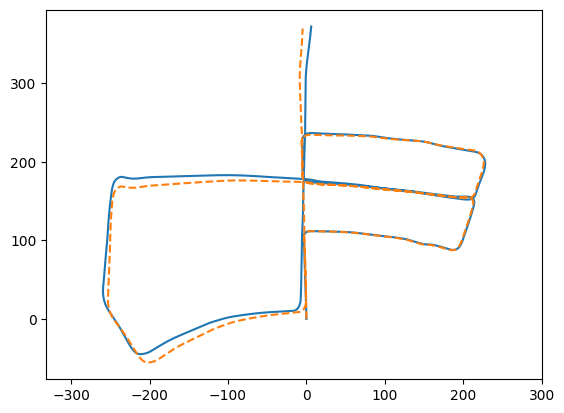

In [100]:
gt_poses, filenames = load_sequence(kitti_path, '05')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 21.016978398491375

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    2668 |   0.576 |   0.003189
     200 |    2573 |   0.641 |   0.002896
     300 |    2479 |   0.686 |   0.002238
     400 |    2267 |   0.642 |   0.001550
     500 |    2177 |   0.616 |   0.001097
     600 |    2049 |   0.572 |   0.000809
     700 |    1952 |   0.505 |   0.000680
     800 |    1861 |   0.473 |   0.000512

Overall: t_err[%]=0.595, r_err[deg/m]=0.001739, samples=18026


(-282.2526275420815, 251.0500613510667, -77.15731728493165, 392.32720854685715)

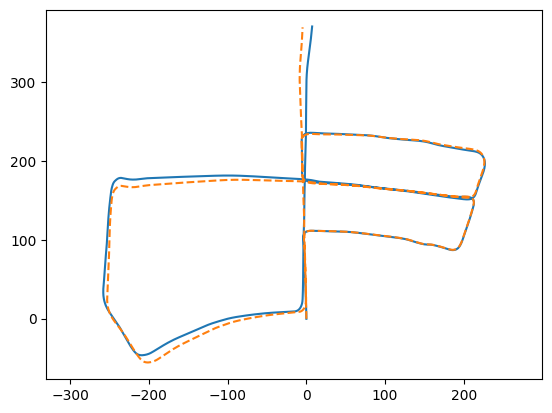

In [101]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 23.354350998545055

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    2668 |   0.880 |   0.002762
     200 |    2573 |   0.906 |   0.002409
     300 |    2479 |   0.879 |   0.002343
     400 |    2267 |   0.803 |   0.002216
     500 |    2177 |   0.723 |   0.001918
     600 |    2049 |   0.651 |   0.001443
     700 |    1952 |   0.572 |   0.001157
     800 |    1861 |   0.550 |   0.001005

Overall: t_err[%]=0.761, r_err[deg/m]=0.001978, samples=18026


(-278.41816629968747,
 255.05950482976263,
 -77.10412410675804,
 391.2101518052114)

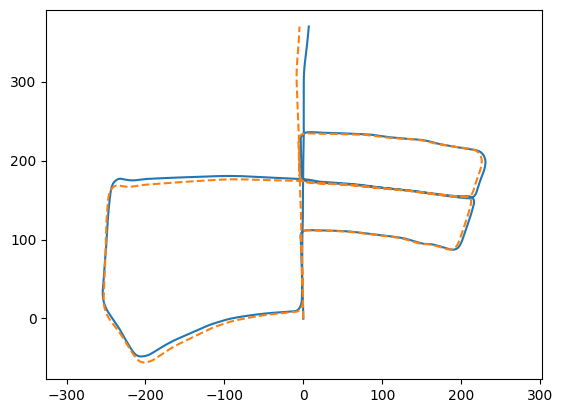

In [102]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 06

## GICP

Avg fps: 6.601246035296451

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     992 |   0.806 |   0.006841
     200 |     915 |   0.960 |   0.005840
     300 |     835 |   1.062 |   0.005067
     400 |     766 |   1.009 |   0.004265
     500 |     653 |   0.816 |   0.003605
     600 |     580 |   0.554 |   0.003077
     700 |     509 |   0.348 |   0.002573
     800 |     411 |   0.282 |   0.002097

Overall: t_err[%]=0.792, r_err[deg/m]=0.004582, samples=5661


(-22.52467163499358, 2.642837810016097, -181.0236591237691, 324.42124167162814)

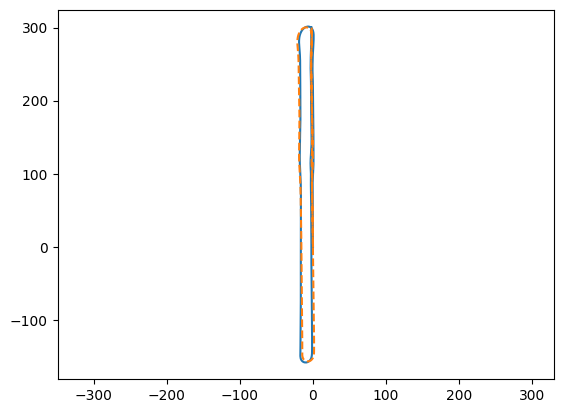

In [103]:
gt_poses, filenames = load_sequence(kitti_path, '06')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 16.303273313968553

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     992 |   0.734 |   0.007284
     200 |     915 |   0.944 |   0.006184
     300 |     835 |   1.078 |   0.005346
     400 |     766 |   1.038 |   0.004483
     500 |     653 |   0.806 |   0.003590
     600 |     580 |   0.526 |   0.002886
     700 |     509 |   0.296 |   0.002268
     800 |     411 |   0.161 |   0.001741

Overall: t_err[%]=0.766, r_err[deg/m]=0.004711, samples=5661


(-22.575050436463805,
 3.700792640890772,
 -180.43028067377418,
 323.91392825840484)

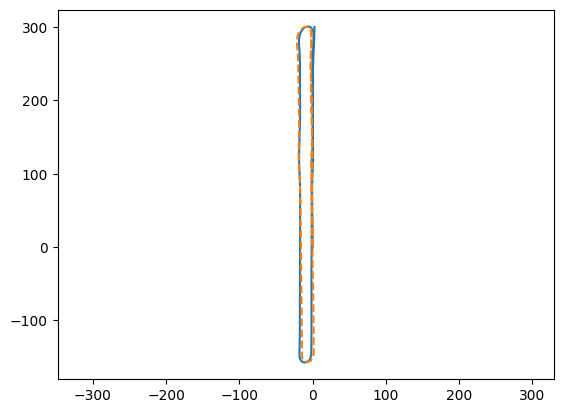

In [104]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 17.37118653356967

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     992 |   0.776 |   0.007277
     200 |     915 |   1.050 |   0.006538
     300 |     835 |   1.234 |   0.005712
     400 |     766 |   1.210 |   0.004809
     500 |     653 |   0.961 |   0.003832
     600 |     580 |   0.701 |   0.003110
     700 |     509 |   0.519 |   0.002511
     800 |     411 |   0.438 |   0.002128

Overall: t_err[%]=0.913, r_err[deg/m]=0.004966, samples=5661


(-22.95307278397869,
 11.639261938703415,
 -179.5236320508992,
 323.86007537025057)

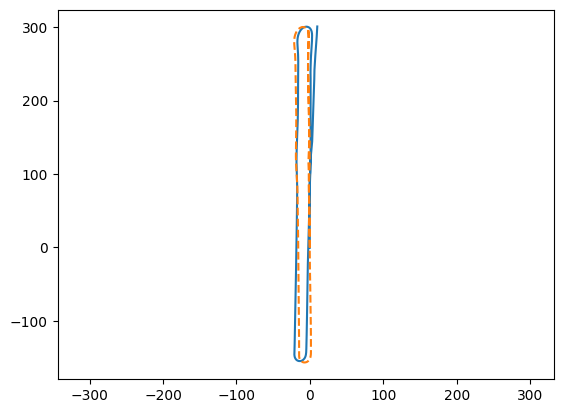

In [105]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 07

## GICP

Avg fps: 12.685702051797055

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     881 |   0.960 |   0.007587
     200 |     788 |   1.024 |   0.004587
     300 |     573 |   1.133 |   0.001559
     400 |     437 |   1.040 |   0.000489
     500 |     295 |   0.779 |   0.000505
     600 |     165 |   0.395 |   0.001211
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=0.972, r_err[deg/m]=0.003745, samples=3139


(-198.85304554475698,
 13.77978633401459,
 -99.83404263736416,
 131.84191126465203)

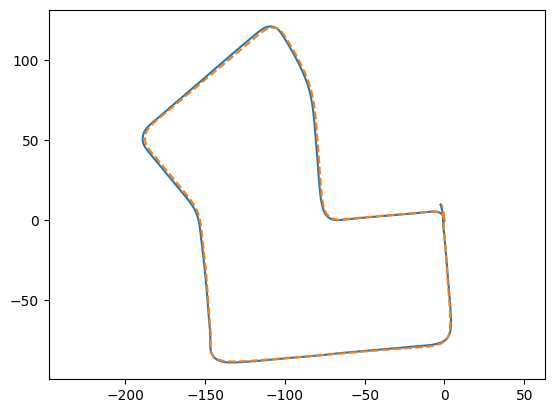

In [106]:
gt_poses, filenames = load_sequence(kitti_path, '07')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 24.36676545088555

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     881 |   0.670 |   0.002996
     200 |     788 |   0.568 |   0.001430
     300 |     573 |   0.503 |   0.000945
     400 |     437 |   0.366 |   0.000367
     500 |     295 |   0.197 |   0.000184
     600 |     165 |   0.122 |   0.000423
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=0.498, r_err[deg/m]=0.001463, samples=3139


(-198.5174578667802, 13.295138561813577, -99.21381517184659, 131.6553497265944)

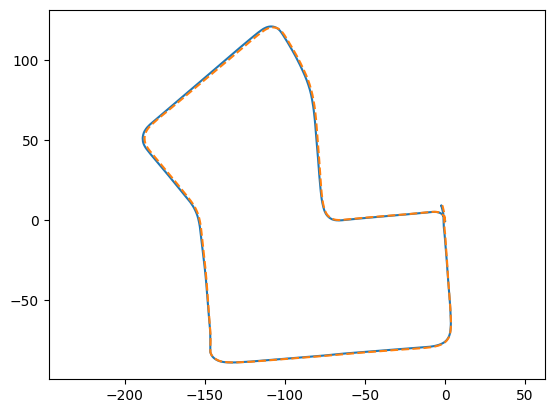

In [107]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 26.87738689840772

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     881 |   1.020 |   0.002488
     200 |     788 |   0.783 |   0.000818
     300 |     573 |   0.610 |   0.000256
     400 |     437 |   0.418 |   0.000026
     500 |     295 |   0.313 |   0.000000
     600 |     165 |   0.321 |   0.000000
     700 |       0 |     nan |        nan
     800 |       0 |     nan |        nan

Overall: t_err[%]=0.699, r_err[deg/m]=0.000954, samples=3139


(-199.98800711636747,
 13.365164716555824,
 -99.2541776962934,
 132.85245492299669)

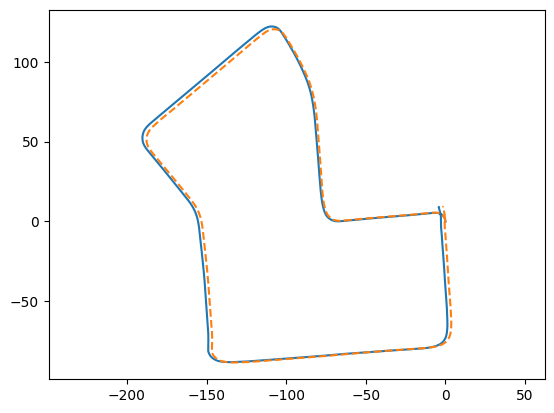

In [108]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 08

## GICP

Avg fps: 8.261950385468241

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    3900 |   1.707 |   0.014117
     200 |    3812 |   1.611 |   0.011516
     300 |    3675 |   1.668 |   0.010230
     400 |    3564 |   1.723 |   0.009156
     500 |    3463 |   1.661 |   0.008324
     600 |    3321 |   1.610 |   0.007874
     700 |    3223 |   1.649 |   0.007574
     800 |    3121 |   1.630 |   0.007284

Overall: t_err[%]=1.659, r_err[deg/m]=0.009662, samples=28079


(-431.3142308793789, 483.8341717061646, -19.8762620645588, 410.05357361338827)

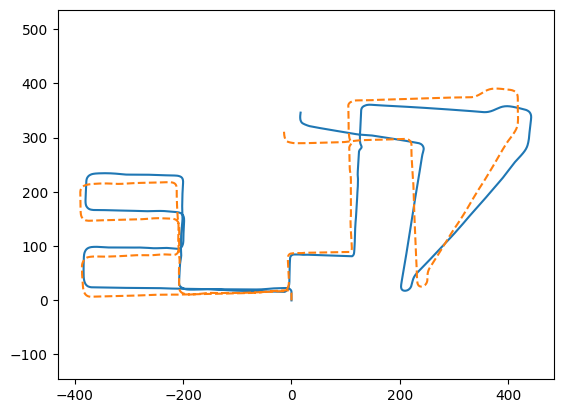

In [109]:
gt_poses, filenames = load_sequence(kitti_path, '08')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 19.381506534832788

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    3900 |   1.566 |   0.002346
     200 |    3812 |   1.413 |   0.001339
     300 |    3675 |   1.376 |   0.000938
     400 |    3564 |   1.323 |   0.000624
     500 |    3463 |   1.131 |   0.000411
     600 |    3321 |   0.935 |   0.000376
     700 |    3223 |   0.813 |   0.000362
     800 |    3121 |   0.727 |   0.000372

Overall: t_err[%]=1.182, r_err[deg/m]=0.000888, samples=28079


(-430.9669851299044, 476.5420109672009, -19.8762620645588, 410.05357361338827)

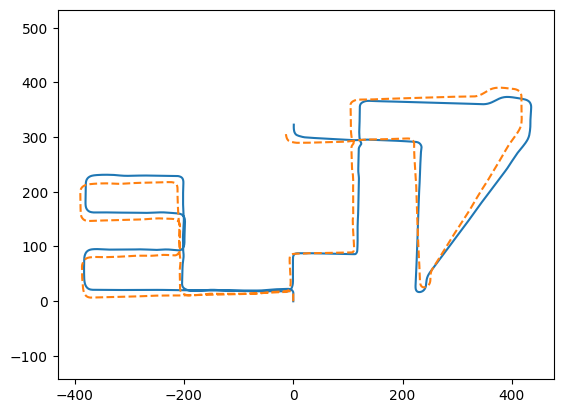

In [110]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 21.38889164467209

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    3900 |   2.041 |   0.010199
     200 |    3812 |   1.715 |   0.007611
     300 |    3675 |   1.520 |   0.006222
     400 |    3564 |   1.357 |   0.005307
     500 |    3463 |   1.210 |   0.004667
     600 |    3321 |   1.060 |   0.004178
     700 |    3223 |   0.900 |   0.003856
     800 |    3121 |   0.800 |   0.003628

Overall: t_err[%]=1.354, r_err[deg/m]=0.005853, samples=28079


(-430.63859089105216,
 469.64573195130373,
 -20.26054833188479,
 418.1235852272341)

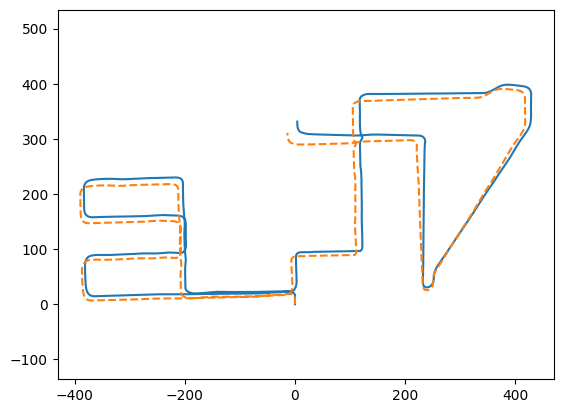

In [111]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 09

## GICP

Avg fps: 8.606573983576068

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    1468 |   0.844 |   0.008906
     200 |    1400 |   0.897 |   0.006661
     300 |    1331 |   1.034 |   0.005754
     400 |    1263 |   1.152 |   0.004921
     500 |    1187 |   1.247 |   0.004218
     600 |    1075 |   1.275 |   0.003488
     700 |     963 |   1.192 |   0.002902
     800 |     859 |   1.138 |   0.002538

Overall: t_err[%]=1.079, r_err[deg/m]=0.005238, samples=9546


(-161.11569454019047,
 350.47274898413195,
 -68.66526537938304,
 566.1306906534857)

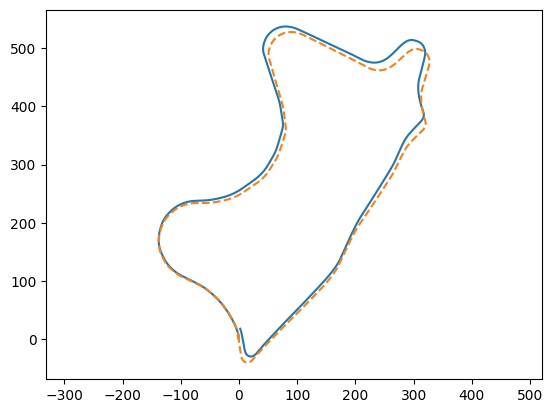

In [112]:
gt_poses, filenames = load_sequence(kitti_path, '09')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 18.589536745257664

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    1468 |   0.818 |   0.007594
     200 |    1400 |   0.887 |   0.005990
     300 |    1331 |   1.025 |   0.005103
     400 |    1263 |   1.131 |   0.004271
     500 |    1187 |   1.219 |   0.003755
     600 |    1075 |   1.247 |   0.003441
     700 |     963 |   1.154 |   0.003115
     800 |     859 |   1.056 |   0.002911

Overall: t_err[%]=1.052, r_err[deg/m]=0.004754, samples=9546


(-161.25964327782373, 350.479603685924, -68.57342357827625, 564.2020128302431)

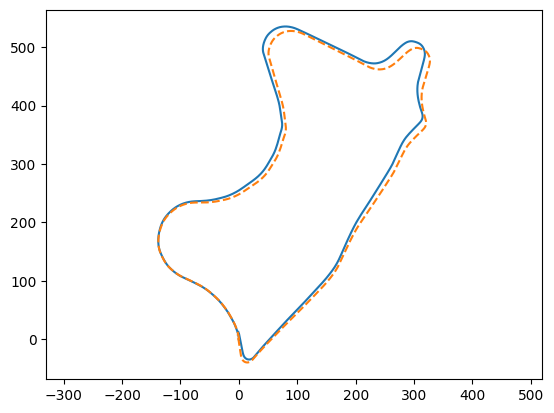

In [113]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 20.675862504842797

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |    1468 |   1.746 |   0.013612
     200 |    1400 |   1.751 |   0.008373
     300 |    1331 |   1.748 |   0.006557
     400 |    1263 |   1.750 |   0.005539
     500 |    1187 |   1.716 |   0.004945
     600 |    1075 |   1.746 |   0.004601
     700 |     963 |   1.707 |   0.004231
     800 |     859 |   1.670 |   0.003881

Overall: t_err[%]=1.733, r_err[deg/m]=0.006877, samples=9546


(-162.18074432247363, 373.81146413673633, -68.2770073948185, 557.9772729776302)

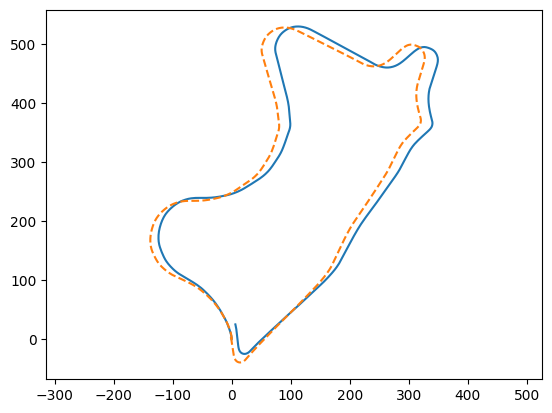

In [114]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

# Sequence 10

## GICP

Avg fps: 12.139365091665452

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     972 |   1.220 |   0.010719
     200 |     836 |   1.235 |   0.008410
     300 |     768 |   1.170 |   0.006850
     400 |     676 |   1.099 |   0.006150
     500 |     509 |   1.050 |   0.005673
     600 |     407 |   1.045 |   0.005119
     700 |     284 |   1.036 |   0.004657
     800 |     151 |   0.851 |   0.004035

Overall: t_err[%]=1.139, r_err[deg/m]=0.007337, samples=4603


(-33.58332140010391,
 704.7368658850255,
 -50.793747938464975,
 156.33064101637424)

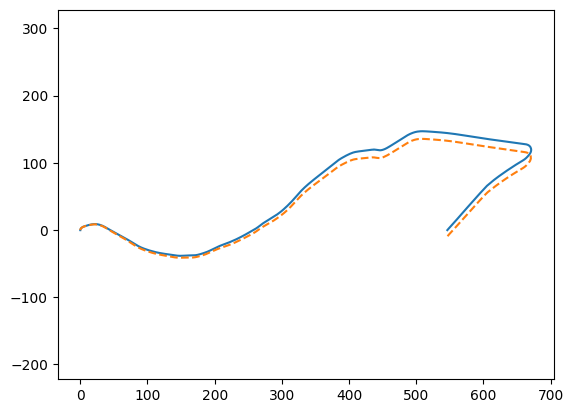

In [115]:
gt_poses, filenames = load_sequence(kitti_path, '10')

reg = pygicp.FastGICP()
reg.set_num_threads(1)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')


## VGICP

Avg fps: 25.14099156897418

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     972 |   0.945 |   0.008781
     200 |     836 |   1.026 |   0.006253
     300 |     768 |   1.221 |   0.004962
     400 |     676 |   1.420 |   0.004359
     500 |     509 |   1.797 |   0.004682
     600 |     407 |   1.968 |   0.004198
     700 |     284 |   2.051 |   0.003764
     800 |     151 |   1.804 |   0.003085

Overall: t_err[%]=1.356, r_err[deg/m]=0.005680, samples=4603


(-33.560830810462654, 704.635604819763, -50.69108378351793, 154.17469376248624)

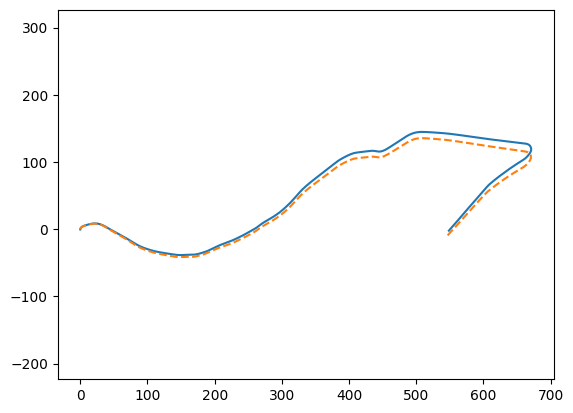

In [116]:
reg = pygicp.FastVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')

## SVGICP

Avg fps: 27.855197595567102

KITTI drift metrics:
Length[m] | samples | t_err[%] | r_err[deg/m]
     100 |     972 |   1.864 |   0.013409
     200 |     836 |   2.089 |   0.009692
     300 |     768 |   2.206 |   0.006969
     400 |     676 |   2.280 |   0.005733
     500 |     509 |   2.659 |   0.005808
     600 |     407 |   2.718 |   0.005011
     700 |     284 |   2.809 |   0.004561
     800 |     151 |   2.770 |   0.004237

Overall: t_err[%]=2.274, r_err[deg/m]=0.008102, samples=4603


(-33.666142419298154, 706.6731325914094, -51.7466859041677, 176.34233829613137)

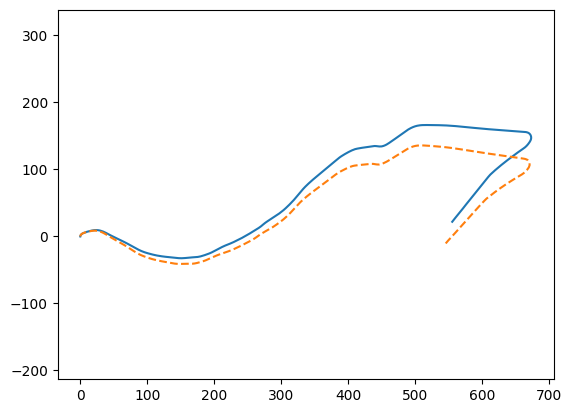

In [117]:
reg = pygicp.FastSVGICP()
reg.set_num_threads(1)
reg.set_resolution(1.0)

stamps = [time.time()]
poses = [gt_poses[0]]
last_delta = numpy.identity(4)

fps_sum = 0
for i, filename in enumerate(filenames):
    points = numpy.fromfile(filename, dtype=numpy.float32).reshape(-1, 4)[:, :3]
    points = pygicp.downsample(points, 0.5)

    if i == 0:
        reg.set_input_target(points)
        delta = numpy.identity(4)
    else:
        reg.set_input_source(points)
        delta = reg.align(initial_guess=last_delta)
        reg.swap_source_and_target()
    
    poses.append(poses[-1].dot(delta))
    last_delta = delta

    if i > 0:
        stamps = stamps[-9:] + [time.time()]
        fps = (len(stamps) / (stamps[-1] - stamps[0]))
        fps_sum += fps
       
print(f"Avg fps: {fps_sum/i}")

est_poses = poses[1:]
gt_eval_poses = gt_poses
summary, overall = compute_kitti_segment_errors(est_poses, gt_eval_poses)
print("\nKITTI drift metrics:")
print("Length[m] | samples | t_err[%] | r_err[deg/m]")
for L in sorted(summary.keys()):
    s = summary[L]
    print(f"{L:8d} | {s['count']:7d} | {s['t_perc_mean']:7.3f} | {s['r_deg_per_m_mean']:10.6f}")
print(f"\nOverall: t_err[%]={overall['t_perc_mean']:.3f}, r_err[deg/m]={overall['r_deg_per_m_mean']:.6f}, samples={overall['num_samples']}")

traj = numpy.array([x[:3, 3] for x in poses])
gt_traj = numpy.array([x[:3, 3] for x in gt_poses])
pyplot.clf()
pyplot.plot(traj[:, 0], traj[:, 2])
pyplot.plot(gt_traj[:, 0], gt_traj[:, 2], '--')
pyplot.axis('equal')